In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score,mean_absolute_error
from xgboost import XGBModel,XGBRanker, XGBRegressor
import matplotlib.pyplot as plt 


In [14]:
class GlowUp():
    def __init__(self,raw_data):
        self.raw_data=raw_data
    def set_no_cap(self,vibe_check,):
        data=self.raw_data
        match(vibe_check):
            case 'water':
               
                data['only_date']=pd.to_datetime(data['only_date']).dt.normalize()
                data['location']=data['sample.samplingPoint.notation'].str.split("-").str[0]
                data.drop(columns=['Unnamed: 0','sample.samplingPoint.label','sample.samplingPoint.northing','sample.samplingPoint.easting'],inplace=True)
                data.fillna(0)
                print("Water Quality Dataset got glow up !")
                return data
            case 'flood':
                
                data.drop(columns=['Unnamed: 0'],inplace=True)
                data.columns=data.columns.str.strip()
                data['only_date']=pd.to_datetime(data['DATE'],errors='coerce').dt.normalize()
                #GRID for Location mapping  
                def no_cap_map_grid(area):
                    area = str(area).upper()
                    if 'NW' in area or 'CUMBRIA' in area or 'LANCASHIRE' in area or 'MANCS' in area: return 'NW'
                    if 'SW' in area or 'DEVON' in area or 'WESSEX' in area or 'CORNWALL' in area: return 'SW'
                    if 'SO' in area or 'SE' in area or 'KENT' in area or 'SUSSEX' in area: return 'SO'
                    if 'TH' in area or 'THAMES' in area or 'HERTS' in area or 'LONDON' in area: return 'TH'
                    if 'ANG' in area or 'ESSEX' in area or 'NORFOLK' in area or 'CAMBRIDGE' in area: return 'ANG'
                    if 'MID' in area or 'LINCS' in area: return 'MD'
                    if 'NE' in area or 'YORK' in area: return 'YORK'
                    return 'OTHER'
                data['Region'] = data['AREA'].apply(no_cap_map_grid)
                target_types = ['Flood Warning', 'Severe Flood Warning']
                data = data[data['TYPE'].isin(target_types)]
                data = data.groupby(['only_date', 'Region']).size().unstack(fill_value=0)
                data['Target_Location'] = data.idxmax(axis=1)
                data = data[['Target_Location']].reset_index()
                # data.columns = [f"{t}_{r}" for r, t in data.columns]
                # data = data.reset_index()
                # data = [c for c in data.columns if c != 'date']
                data=pd.DataFrame(data)
                data.fillna(0)
                return data
            case 'sky':
                
                data['only_date'] = pd.to_datetime(data['date'], dayfirst=True).dt.normalize()
                data['rain_lag1'] = data['precipitation'].shift(1).fillna(0)
                for col in ['precipitation', 'temp', 'surface_runoff']:
                    data[f'{col}_lag1'] = data[col].shift(1)
                    data[f'{col}_lag2'] = data[col].shift(2)
                    data[f'{col}_mean3d'] = data[col].rolling(window=3).mean()
                    data[f'{col}_mean7d'] = data[col].rolling(window=7).mean()
                    
                #shift is to  where  data has been deployed   where it has been deployed 
                data.drop(columns=['date'])
                return data
   
            

In [ ]:

# all water datasets are grouped into single dataframe
df_list=[]
for csv_num in range(5):
    path=f"data/water_quality{csv_num}.csv"
    clean_data=pd.read_csv(path)
    call_back=GlowUp(clean_data)
    cleaned_data=call_back.set_no_cap('water')
    df_list.append(cleaned_data)
water_data=pd.concat(df_list)

#FLOOD DATA CLEANING
flood_data=pd.read_csv(r'data/flood_datalogs.csv')
flood_data=GlowUp(flood_data)
flood_data_clean=flood_data.set_no_cap('flood')

#UK CLIMATE CLEANING
climate_data=pd.read_csv(r'data/uk_climate.csv')
climate_data=GlowUp(climate_data)
climate_data_clean=climate_data.set_no_cap('sky')

water_data_cols=['Alky pH 4.5', 'Ammonia(N)', 'BOD ATU', 'Cond @ 25C', 'Oxygen Diss', 'Temp Water', 'pH', 'Sld Sus@105C','Nitrate-N','Phosphorus-P','is_sewage']
water_data=water_data.groupby('only_date')[water_data_cols].mean().reset_index()
water_data.columns=['only_date']+[f'water_avg_{col}'for col in water_data_cols]
water_data.shape
#merging all three datasets
stan_fam=pd.merge(water_data,climate_data_clean,on='only_date',how='inner')
stan_fam=stan_fam.merge(flood_data_clean,on='only_date',how='left')
stan_fam.fillna(0,inplace=True)
stan_fam['Target_Location'] = stan_fam['Target_Location'].fillna('NONE').astype(str)
stan_fam.columns

Water Quality Dataset got glow up !
Water Quality Dataset got glow up !
Water Quality Dataset got glow up !
Water Quality Dataset got glow up !
Water Quality Dataset got glow up !


Index(['only_date', 'water_avg_Alky pH 4.5', 'water_avg_Ammonia(N)',
       'water_avg_BOD ATU', 'water_avg_Cond @ 25C', 'water_avg_Oxygen Diss',
       'water_avg_Temp Water', 'water_avg_pH', 'water_avg_Sld Sus@105C',
       'water_avg_Nitrate-N', 'water_avg_Phosphorus-P', 'water_avg_is_sewage',
       'date', 'decade', 'year', 'season', 'month', 'day', 'day_of_year',
       'temp', 'wind_speed', 'precipitation', 'surface_runoff',
       'dewpoint_temp', 'rain_lag1', 'precipitation_lag1',
       'precipitation_lag2', 'precipitation_mean3d', 'precipitation_mean7d',
       'temp_lag1', 'temp_lag2', 'temp_mean3d', 'temp_mean7d',
       'surface_runoff_lag1', 'surface_runoff_lag2', 'surface_runoff_mean3d',
       'surface_runoff_mean7d', 'Target_Location'],
      dtype='object')

#### Engineering Slayed Here

In [16]:
stan_fam = stan_fam[(stan_fam['water_avg_Cond @ 25C'] > 0) & (stan_fam['water_avg_Oxygen Diss'] > 0)].copy()
stan_fam

,only_date,water_avg_Alky pH 4.5,water_avg_Ammonia(N),water_avg_BOD ATU,water_avg_Cond @ 25C,water_avg_Oxygen Diss,water_avg_Temp Water,water_avg_pH,water_avg_Sld Sus@105C,water_avg_Nitrate-N,...,precipitation_mean7d,temp_lag1,temp_lag2,temp_mean3d,temp_mean7d,surface_runoff_lag1,surface_runoff_lag2,surface_runoff_mean3d,surface_runoff_mean7d,Target_Location
0,2020-01-02,44.000000,2.539746,7.542754,8607.571429,11.700000,9.716667,7.451176,12.638056,36.163333,...,3.577471,4.95248,4.35598,5.530330,6.584546,0.006244,0.021455,0.047058,0.081839,0
4,2020-01-06,179.076705,1.117752,39.953979,768.942408,10.986878,7.893531,7.878208,36.078164,8.584949,...,4.248090,6.92350,5.89770,6.590067,6.052339,0.055399,0.116075,0.098904,0.091911,0
5,2020-01-07,178.019048,0.986463,30.640135,916.353616,10.974502,7.681736,7.816000,22.885740,6.566822,...,5.742197,6.94900,6.92350,7.268260,6.563239,0.125239,0.055399,0.214438,0.154942,0
6,2020-01-08,179.298636,0.745913,27.810385,1091.708311,10.388500,8.762632,7.835517,12.601866,6.263323,...,6.803929,7.93228,6.94900,7.322110,6.867891,0.462675,0.125239,0.298246,0.197882,0
7,2020-01-09,163.822622,1.376889,33.384459,717.532641,10.528891,8.746202,7.767562,42.498912,5.768414,...,8.364360,7.08505,7.93228,6.749377,6.574787,0.306824,0.462675,0.444732,0.262342,MD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,2024-12-19,202.674603,1.129115,43.732270,428.451020,10.041154,8.615000,7.601679,21.485057,4.616286,...,7.344506,9.91543,8.02740,7.412033,7.082293,0.628799,0.255686,0.519080,0.310543,MD
1793,2024-12-20,208.571429,0.843375,41.040769,624.000000,7.555000,8.880000,7.460000,21.770000,3.233083,...,8.378261,4.29327,9.91543,6.393567,7.167854,0.672755,0.628799,0.527715,0.346596,MD
1796,2024-12-23,169.166667,0.063057,62.100000,422.071429,11.966667,6.282143,7.619643,6.220000,4.461667,...,10.128323,4.19952,6.59040,5.231760,6.129054,0.210043,0.374183,0.220700,0.357276,0
1802,2024-12-30,485.028571,25.095755,108.700000,674.976190,11.400000,7.785714,7.742449,296.802857,8.752571,...,5.068616,6.89740,6.00750,6.646013,7.574574,0.177401,0.060964,0.455189,0.231315,TH


In [17]:
#featuring the non targeted columns
feature_cols = [c for c in stan_fam.columns if c not in ['only_date', 'Target_Location', 'water_avg_Cond @ 25C','water_avg_Oxygen Diss']]
X = stan_fam[feature_cols].select_dtypes(include=np.number).values



#### Feed Forward Neural Network 

In [18]:
#feed the neural network with scaling factor for the targeted prediction values
scaler_y_ox = StandardScaler()
Y_ox = scaler_y_ox.fit_transform(stan_fam[['water_avg_Oxygen Diss']])
scaler_y_ni = StandardScaler()
Y_ni = scaler_y_ni.fit_transform(stan_fam[['water_avg_Cond @ 25C']])
#classifying the location 
le = LabelEncoder()
Y_loc = to_categorical(le.fit_transform(stan_fam['Target_Location']))

In [19]:
X_train, X_test, y_ox_train, y_ox_test, y_ni_train, y_ni_test, y_loc_train, y_loc_test = train_test_split(X, Y_ox, Y_ni, Y_loc, test_size=0.2, random_state=42)
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

In [ ]:
input_dim = X_train_scaled.shape[1]
input_layer = Input(shape=(input_dim,), name='input_features')
class modelPrediction():
    def __init__(self,y_ox_train,y_ox_test,y_ni_train,y_ni_test,y_loc_train,y_loc_test,Y_loc):
        self.y_ox_train =y_ox_train
        self.y_ox_test=y_ox_test
        self.y_ni_train=y_ni_train
        self.y_ni_test=y_ni_test
        self.y_loc_train=y_loc_train
        self.y_loc_test=y_loc_test
        self.Y_loc=Y_loc
    
    def fnn(self):
        y_ox_train= self.y_ox_train
        y_ox_test= self.y_ox_test
        y_ni_train= self.y_ni_train
        y_ni_test=self.y_ni_test
        y_loc_train=self.y_loc_train
        y_loc_test=self.y_loc_test
        Y_loc=self.Y_loc
        
        
        x = Dense(128, activation='relu')(input_layer)
        x = BatchNormalization()(x)
        x = Dropout(0.3)(x)
        x = Dense(64, activation='relu')(x)
        x = BatchNormalization()(x)
        x = Dropout(0.2)(x)
        n_classes = y_loc_train.shape[1]

        head_ox = Dense(1, activation='linear', name='out_ox')(x)
        head_ni = Dense(1, activation='linear', name='out_ni')(x)
        head_loc = Dense(n_classes, activation='softmax', name='out_loc')(x)

        model = Model(inputs=input_layer, outputs=[head_ox, head_ni, head_loc])
        model.compile(
            optimizer=Adam(learning_rate=0.005),
            loss={'out_ox': 'mse', 'out_ni': 'mse', 'out_loc': 'categorical_crossentropy'},
            loss_weights={'out_ox': 1.0, 'out_ni': 5.0, 'out_loc': 0.2}
        )

        print("\nTraining Model...")
        history=model.fit(
            X_train_scaled, [y_ox_train, y_ni_train, y_loc_train],
            epochs=50, batch_size=32, verbose=0,
            validation_data=(X_test_scaled, [y_ox_test, y_ni_test, y_loc_test])
        )

        #model Evaluate
        preds = model.predict(X_test_scaled, verbose=0)

        print(f"Oxygen dissolved MAE: {mean_absolute_error(y_ox_test,preds[0])}")
        print(f"concuctivity/Salinity MAE: {mean_absolute_error(y_ni_test,preds[1])}")
        print(f"LOCATION  MAE: {mean_absolute_error(y_loc_test,preds[2])}")
        #Accuracy Score 
        r2_ox = r2_score(scaler_y_ox.inverse_transform(y_ox_test), scaler_y_ox.inverse_transform(preds[0]))
        r2_ni = r2_score(scaler_y_ni.inverse_transform(y_ni_test), scaler_y_ni.inverse_transform(preds[1]))
        acc_loc = accuracy_score(np.argmax(y_loc_test, axis=1), np.argmax(preds[2], axis=1))
        total_loss = model.evaluate(X_test_scaled, [y_ox_test, y_ni_test, y_loc_test], verbose=0)[0]
        print("\n--- Final Results After Fix ---")
        print(f"1. Oxygen Dissolved (R2): {r2_ox:.4f} ")
        print(f"2. conductiviy  (R2): {r2_ni:.4f}")
        print(f"3. Flood Location (Accuracy): {acc_loc:.4f}")
        print("\n--- Final Results After Loss Weight Adjustment ---")
        
        print(f"Total Combined Loss: {total_loss:.4f}")
        print(f"1. Oxygen Dissolved (R2): {r2_ox:.4f}")
        print(f"2. conductivity (R2): {r2_ni:.4f}")
        print(f"3. Flood Location (Accuracy): {acc_loc:.4f}")
        history_model=pd.DataFrame(history.history)
        return history_model
    



In [27]:

#Run the Feed Forward Neural Network.
runModel= modelPrediction(y_ox_train,y_ox_test,y_ni_train,y_ni_test,y_loc_train,y_loc_test,Y_loc)
runModel.fnn()



Training Model...
OXYGEN 0.3020925998065093
concuctivity 0.26972259002303584
LOCATION 0.12493135836671954

--- Final Results After Fix ---
1. Oxygen Dissolved (R2): 0.7406 
2. conductiviy  (R2): 0.3059
3. Flood Location (Accuracy): 0.6862

--- Final Results After Loss Weight Adjustment ---
Total Combined Loss: 3.3390
1. Oxygen Dissolved (R2): 0.7406
2. conductivity (R2): 0.3059
3. Flood Location (Accuracy): 0.6862


,loss,out_loc_loss,out_ni_loss,out_ox_loss,val_loss,val_out_loc_loss,val_out_ni_loss,val_out_ox_loss
0,11.468478,2.052043,1.939983,1.410530,4.352747,2.110281,0.704223,0.627647
1,5.860898,1.629273,1.002663,0.569589,3.903560,1.651002,0.640802,0.537975
2,5.247087,1.365213,0.907019,0.430921,3.692381,1.389456,0.624319,0.476188
3,4.575042,1.251374,0.792050,0.355650,3.218564,1.235657,0.522368,0.466778
4,4.571969,1.180297,0.800881,0.322966,2.885487,1.134935,0.455389,0.385244
5,3.728229,1.108699,0.638362,0.312389,2.614857,1.100178,0.402172,0.368960
6,4.076249,1.034570,0.712155,0.297071,2.842895,1.073254,0.470251,0.336325
7,3.548663,1.024139,0.614386,0.283359,2.808694,1.052589,0.459973,0.364994
8,3.470691,0.975203,0.599284,0.269442,2.864086,1.026388,0.485273,0.350100
9,3.175481,0.962377,0.543255,0.275290,2.721513,1.027786,0.449354,0.344577


In [22]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score
X_train, X_test, y_train, y_test = train_test_split(X, Y_ni, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn_reg = KNeighborsRegressor(
    n_neighbors=9,
    weights='distance',
    metric='minkowski',
    p=2
)
knn_reg.fit(X_train_scaled, y_train)
y_pred = knn_reg.predict(X_test_scaled)
# print("MAE:", mean_absolute_error(y_test, y_pred))
# print("R2:", r2_score(y_test, y_pred))

In [23]:

Y_ni = stan_fam['water_avg_Cond @ 25C'].values
X_train_ni, X_test_ni, Y_train_ni, Y_test_ni = train_test_split(X, Y_ni, test_size=0.2, random_state=42)
rf_regressor_ni = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_regressor_ni.fit(X_train_ni, Y_train_ni)
Y_pred_ni = rf_regressor_ni.predict(X_test_ni)
r2_ni = r2_score(Y_test_ni, Y_pred_ni)
rmse_ni = np.sqrt(mean_squared_error(Y_test_ni, Y_pred_ni))


Y_ox = stan_fam['water_avg_Oxygen Diss'].values
X_train_ox, X_test_ox, Y_train_ox, Y_test_ox = train_test_split(X, Y_ox, test_size=0.2, random_state=42)
rf_regressor_ox = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_regressor_ox.fit(X_train_ox, Y_train_ox)
Y_pred_ox = rf_regressor_ox.predict(X_test_ox)
r2_ox = r2_score(Y_test_ox, Y_pred_ox)
rmse_ox = np.sqrt(mean_squared_error(Y_test_ox, Y_pred_ox))


Y_loc = stan_fam['Target_Location'].values
X_train_loc, X_test_loc, Y_train_loc, Y_test_loc = train_test_split(X, Y_loc, test_size=0.2, random_state=42)
rf_classifier_loc = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_classifier_loc.fit(X_train_loc, Y_train_loc)
Y_pred_loc = rf_classifier_loc.predict(X_test_loc)
acc_loc = accuracy_score(Y_test_loc, Y_pred_loc)


print("--- Random Forest Model Results ---")
print(f"1. conductivity: {r2_ni:.4f}")
print(f"1. conductivity: {rmse_ni:.4f} mg/L")
print(f"2. Oxygen Dissolved (R2): {r2_ox:.4f}")
print(f"2. Oxygen Dissolved (RMSE): {rmse_ox:.4f} mg/L")
print(f"3. Flood Location (Accuracy): {acc_loc:.4f}")

--- Random Forest Model Results ---
1. conductivity: 0.8143
1. conductivity: 1168.8995 mg/L
2. Oxygen Dissolved (R2): 0.7771
2. Oxygen Dissolved (RMSE): 0.6410 mg/L
3. Flood Location (Accuracy): 0.6987


In [24]:

plt.figure(figsize=(8,6))
plt.plot(history_model['out_ox_loss'],label='training loss')
plt.plot(history_model['val_out_ox_loss'],label='validation loss')
plt.title("Oxygen training and validation label for the epochs")
plt.xlabel('Epochs')
plt.ylabel('oxygen loss peak')
plt.legend()
plt.show()
plt.figure(figsize=(8,6))
plt.plot(history_model['out_ni_loss'],label='training loss')
plt.plot(history_model['val_out_ni_loss'],label='validation loss')
plt.title("conductivity/salinity  training and validation label for the epochs")
plt.xlabel('Epochs')
plt.ylabel('conductivity_salinity loss peak')
plt.legend()
plt.show()

NameError: name 'history_model' is not defined

<Figure size 800x600 with 0 Axes>

AVERAGE-1.184218362404805


(0.0, 1.0)

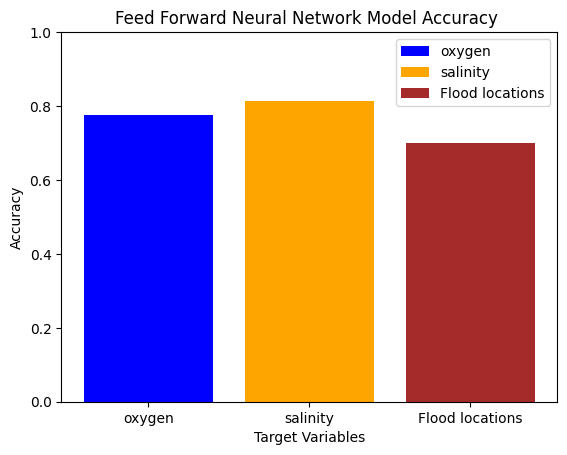

In [ ]:
from cProfile import label
from turtle import color
avg_model_accuracy=r2_ox+r2_ni/2
print(f"AVERAGE-{avg_model_accuracy}")

targets = ["oxygen", "salinity", "Flood locations"]
accuracy_scores = [r2_ox, r2_ni,acc_loc ]

plt.figure()
plt.bar(targets, accuracy_scores,color=['blue','orange','brown'],label=targets)

plt.xlabel("Target Variables")
plt.ylabel("Accuracy")
plt.title("Feed Forward Neural Network Model Accuracy ")
plt.legend()
plt.ylim(0, 1)

##### Hyper parameter tuning 

/home/leodas/Desktop/ML_PROJECT/mllib/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/leodas/Desktop/ML_PROJECT/mllib/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/leodas/Desktop/ML_PROJECT/mllib/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/leodas/Desktop/ML_PROJECT/mllib/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vec


--- Random Forest Hyperparameter Tuning Results (Conductivity) ---
Best Parameters Found: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 30}
Tuned R-squared on Test Set: 0.7683


Loading datasets...
Engineering features and composite scores...
Tuning Random Forest...
Tuning Gradient Boosting...


/home/leodas/Desktop/ML_PROJECT/mllib/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Training FFNN...

Random Forest R2: 0.4583
Gradient Boosting R2: 0.5066
Neural Network R2: 0.3581
Visualization saved as result_plot.png


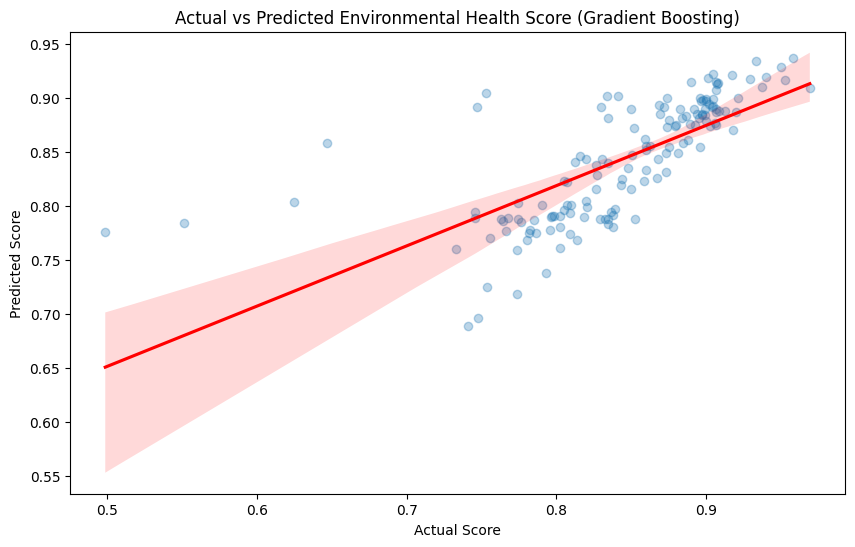

Final FNN Model Performance:
RMSE: 0.9724
R2 Score: 0.5854


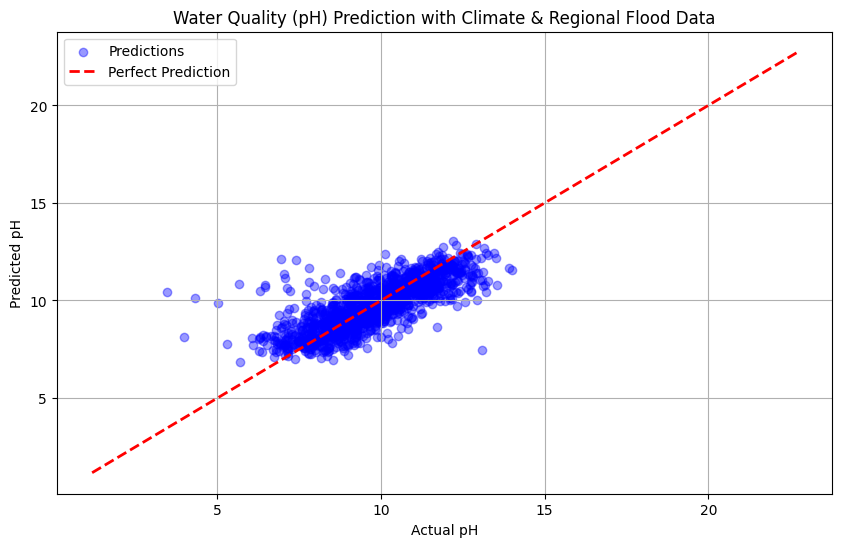

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Load Data
climate_df = pd.read_csv('data/uk_climate.csv')
flood_df = pd.read_csv('data/flood_datalogs.csv')
wq_files = ['data/water_quality0.csv', 'data/water_quality1.csv', 'data/water_quality2.csv', 'data/water_quality3.csv', 'data/water_quality4.csv']
wq_combined = pd.concat([pd.read_csv(f) for f in wq_files], ignore_index=True)

# 2. Date and Region Preprocessing
climate_df['date'] = pd.to_datetime(climate_df['date'], format='%d/%m/%Y')
flood_df['date'] = pd.to_datetime(flood_df['DATE']).dt.normalize()
wq_combined['date'] = pd.to_datetime(wq_combined['only_date'])

mapping = {
    'SW': 'SW', 'ANG': 'AN', 'East Anglia': 'AN', 'Lincs': 'AN',
    'SOU': 'SO', 'Solent': 'SO', 'Kent': 'SO', 'SE': 'SO',
    'MID': 'MD', 'West Midlands': 'MD', 'East Midlands': 'MD',
    'NE': 'NE', 'Yorkshire': 'NE', 'North East': 'NE',
    'NW': 'NW', 'Cumbria': 'NW', 'Gtr Mancs': 'NW',
    'TH': 'TH', 'Thames': 'TH', 'Herts': 'TH',
    'Devon': 'SW', 'Cornwall': 'SW', 'Wessex': 'SW'
}

def get_region(area_str):
    for key, val in mapping.items():
        if key in str(area_str): return val
    return 'Other'

flood_df['region_code'] = flood_df['AREA'].apply(get_region)
wq_combined['region_code'] = wq_combined['sample.samplingPoint.notation'].apply(lambda x: str(x).split('-')[0])

# Filter WQ to primary regions
valid_regions = ['SW', 'AN', 'SO', 'MD', 'NE', 'NW', 'TH']
wq_filtered = wq_combined[wq_combined['region_code'].isin(valid_regions)]

# 3. Aggregate
flood_daily = flood_df.groupby(['date', 'region_code']).size().reset_index(name='flood_count')
# We'll use pH as the target
wq_daily = wq_filtered.groupby(['date', 'region_code'])['Oxygen Diss'].mean().reset_index()

# 4. Merge
merged_regional = pd.merge(wq_daily, flood_daily, on=['date', 'region_code'], how='left')
merged_regional['flood_count'] = merged_regional['flood_count'].fillna(0)
final_df = pd.merge(merged_regional, climate_df, on='date', how='inner')

# Drop NaNs in target
final_df = final_df.dropna(subset=['Oxygen Diss'])

# 5. Feature Engineering
# One-hot encode region
final_df = pd.get_dummies(final_df, columns=['region_code'], prefix='reg')

# Temporal features
final_df['month_sin'] = np.sin(2 * np.pi * final_df['month'] / 12)
final_df['month_cos'] = np.cos(2 * np.pi * final_df['month'] / 12)

# Define Features
feature_cols = [
    'temp', 'wind_speed', 'precipitation', 'surface_runoff', 'dewpoint_temp', 
    'flood_count', 'month_sin', 'month_cos'
] + [c for c in final_df.columns if c.startswith('reg_')]

X = final_df[feature_cols]
y = final_df['Oxygen Diss']

# 6. Model Training (FNN)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Feed-Forward Neural Network (Multi-Layer Perceptron)
# Deep architecture for better pattern recognition
fnn = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=32,
    learning_rate='adaptive',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

fnn.fit(X_train_scaled, y_train)

# 7. Evaluate
y_pred = fnn.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Final FNN Model Performance:")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

# Plot Results
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='blue', label='Predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual pH')
plt.ylabel('Predicted pH')
plt.title('Water Quality (pH) Prediction with Climate & Regional Flood Data')
plt.legend()
plt.grid(True)
plt.savefig('fnn_prediction_results.png')

# Save model predictions for user
pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}).to_csv('fnn_water_quality_results.csv', index=False)